In [46]:
import polars as pl
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import QuantileRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import RobustScaler
from sktime.forecasting.chronos import ChronosForecaster
from sktime.forecasting.conformal import ConformalIntervals

from sktime.forecasting.model_selection import ForecastingGridSearchCV
from sktime.forecasting.compose import make_reduction, TransformedTargetForecaster, ForecastingPipeline
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.arima import AutoARIMA
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.performance_metrics.forecasting.probabilistic import PinballLoss
from sktime.split import ExpandingWindowSplitter, temporal_train_test_split
from sktime.transformations.compose import OptionalPassthrough
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sktime.transformations.series.detrend import Detrender, Deseasonalizer
from sktime.transformations.series.impute import Imputer

# Data Prep

In [47]:
data = (pl.read_csv('../../data/processed/final_feature_df.csv',
                   try_parse_dates=True,
                   columns=['date', 'sales', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos', 'is_lecture_day', 'is_regular_service_day', 'sunshine_duration', 'apparent_temperature_mean',],
                   )
        .filter(pl.col('is_regular_service_day'))
        .drop('is_regular_service_day')
        .with_columns(pl.col('is_lecture_day').cast(pl.Float64))
        )
data

date,week_sin,week_cos,month_sin,month_cos,year_sin,year_cos,is_lecture_day,sunshine_duration,apparent_temperature_mean,sales
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
2025-01-06,0.0,1.0,0.858764,0.512371,0.085965,0.996298,1.0,4.9225845,-1.277526,1866
2025-01-07,0.781831,0.62349,0.945596,0.325342,0.103102,0.994671,1.0,0.0,-0.479467,2224
2025-01-08,0.974928,-0.222521,0.992222,0.124479,0.120208,0.992749,1.0,0.1398955,1.6230611,2153
2025-01-09,0.433884,-0.900969,0.996659,-0.081676,0.137279,0.990532,1.0,4.0080094,-3.397642,1739
2025-01-10,-0.433884,-0.900969,0.958718,-0.284359,0.154309,0.988023,1.0,0.4939937,-3.33542,1366
…,…,…,…,…,…,…,…,…,…,…
2025-12-15,0.0,1.0,0.361714,-0.932289,-0.288482,0.957485,1.0,6.0202994,3.3126433,1408
2025-12-16,0.781831,0.62349,0.162807,-0.986658,-0.271958,0.962309,1.0,4.8902845,2.2815366,1483
2025-12-17,0.974928,-0.222521,-0.043022,-0.999074,-0.255353,0.966848,1.0,4.644257,5.767552,1459


In [48]:
data_pd = data.to_pandas().set_index("date")
data_pd["original_date"] = data_pd.index

data_pd.index = pd.period_range(
    start=data_pd.index.min(),
    periods=len(data_pd),
    freq="B",
)

y = data_pd["sales"]
X = data_pd.drop(columns=["sales", "original_date"])

C:\Users\valen\AppData\Local\Temp\ipykernel_9068\1986072616.py:4: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  data_pd.index = pd.period_range(
C:\Users\valen\AppData\Local\Temp\ipykernel_9068\1986072616.py:4: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  data_pd.index = pd.period_range(


In [49]:
y = y.interpolate().ffill().bfill()
X = X.ffill().bfill()

# Pipeline Setup

## Preprocessors

In [50]:
pipe_y = TransformedTargetForecaster(
    steps=[
        ("y_imputer", Imputer(method="constant", value=0)),
        ("detrender", OptionalPassthrough(Detrender())),
        ("deseasonalizer", OptionalPassthrough(Deseasonalizer())),
        ("scaler", TabularToSeriesAdaptor(RobustScaler())),
        ("forecaster", NaiveForecaster(strategy="mean", sp=5)),
    ]
)

In [51]:
pipe = ForecastingPipeline(
    steps=[
        ("x_scaler", TabularToSeriesAdaptor(RobustScaler())),
        ("forecaster", pipe_y),
    ]
)

## Params

In [52]:
proba_forecaster_param_grid = [
    # Naive baseline
    {
        "detrender__passthrough": [True, False],
        "deseasonalizer__passthrough": [True, False],
        "forecaster": [
            NaiveForecaster(strategy="last", sp=5),
            NaiveForecaster(strategy="mean", sp=5),
        ],
    },

    # SARIMAX
    {
        "detrender__passthrough": [True],
        "deseasonalizer__passthrough": [True],
        "forecaster": [
            AutoARIMA(
                sp=5,
                suppress_warnings=True,
                n_jobs=-1),
        ],
        "forecaster__seasonal": [True, False],
        "forecaster__max_p": [2, 4],
        "forecaster__max_q": [2, 4],
        "forecaster__max_P": [1, 2],
        "forecaster__max_Q": [1, 2],
    },
]

point_forecaster_param_grid = [
    # Gradient boosting
    {
        "forecaster__detrender__passthrough": [True, False],
        "forecaster__deseasonalizer__passthrough": [True, False],
        "forecaster__forecaster": [
            make_reduction(
                HistGradientBoostingRegressor(loss="squared_error", random_state=42),
                strategy="recursive",
                window_length=5,
            )
        ],
        "forecaster__forecaster__window_length": [5, 10, 20],
        "forecaster__forecaster__estimator__max_iter": [100, 300],
        "forecaster__forecaster__estimator__learning_rate": [0.01, 0.1],
        "forecaster__forecaster__estimator__max_leaf_nodes": [15, 31],
        "forecaster__forecaster__estimator__l2_regularization": [0.0, 0.1],
    },

    # Quantile regression
    {
        "forecaster__detrender__passthrough": [True, False],
        "forecaster__deseasonalizer__passthrough": [True, False],
        "forecaster__forecaster": [
            make_reduction(
                QuantileRegressor(quantile=0.5, solver="highs"),
                strategy="recursive",
                window_length=5,
            )
        ],
        "forecaster__forecaster__window_length": [5, 10, 20],
        "forecaster__forecaster__estimator__alpha": [0.01, 0.1, 1.0],
    },

    # KNN
    {
        "forecaster__detrender__passthrough": [True, False],
        "forecaster__deseasonalizer__passthrough": [True, False],
        "forecaster__forecaster": [
            make_reduction(
                KNeighborsRegressor(weights='distance', n_jobs=-1), # weight by distance for a stronger effect of close neighbors
                strategy="recursive",
                window_length=5,
            )
        ],
        "forecaster__forecaster__window_length": [5, 10, 20],
        "forecaster__forecaster__estimator__n_neighbors": [3, 5, 10],
        "forecaster__forecaster__estimator__p": [1, 2],
    },

    # Chronos Foundation Model, no detrending and deseasonalization is done here because the model can handle this type of data
    {
        "forecaster__detrender__passthrough": [True],
        "forecaster__deseasonalizer__passthrough": [True],
        "forecaster__forecaster": [
            ChronosForecaster(
                model_path="amazon/chronos-t5-base",
                seed=42,
            ),
        ],
    },
]

In [53]:
fh = [1,2,3,4,5]

# expanding window splitter with 4 weeks á 5 days initial window length and 5 working day stride, only works because the data starts at monday and excludes weekends, problems may arise when holidays occur
cv = ExpandingWindowSplitter(fh=fh, initial_window=30, step_length=5)
proba_scoring = PinballLoss(alpha=[0.1, 0.25, 0.5, 0.75, 0.9])
point_scoring = MeanAbsolutePercentageError()

## Grid Search

In [54]:
y_train, y_test, X_train, X_test = temporal_train_test_split(y, X, fh=fh)

In [55]:
# for the two probabilistic models we do not use exogeneous variables for now, the naive case doesnt care about X and ARIMA does not work with exogeneous at the moment -> TODO: fix later
proba_gscv = ForecastingGridSearchCV(pipe_y, cv=cv, param_grid=proba_forecaster_param_grid, scoring=proba_scoring, error_score="raise")
point_gscv = ForecastingGridSearchCV(pipe, cv=cv, param_grid=point_forecaster_param_grid, scoring=point_scoring, error_score="raise")

In [56]:
proba_gscv.fit(y_train, fh=fh)
proba_gscv.save("../../models/proba_gscv")
proba_gscv.best_params_

C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '
C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


{'deseasonalizer__passthrough': True,
 'detrender__passthrough': True,
 'forecaster': AutoARIMA(max_P=1, max_Q=1, max_p=2, max_q=4, n_jobs=-1, sp=5,
           suppress_warnings=True),
 'forecaster__max_P': 1,
 'forecaster__max_Q': 1,
 'forecaster__max_p': 2,
 'forecaster__max_q': 4,
 'forecaster__seasonal': True}

In [24]:
point_gscv.fit(y_train, X=X_train, fh=fh)
point_gscv.save("../../models/point_gscv")
point_gscv.best_params_

{'forecaster__deseasonalizer__passthrough': True,
 'forecaster__detrender__passthrough': True,
 'forecaster__forecaster': RecursiveTabularRegressionForecaster(estimator=KNeighborsRegressor(n_jobs=-1, n_neighbors=3, p=1, weights='distance'),
                                      window_length=5),
 'forecaster__forecaster__estimator__n_neighbors': 3,
 'forecaster__forecaster__estimator__p': 1,
 'forecaster__forecaster__window_length': 5}

### Load GridSearch results from disk

In [78]:
proba_gscv = ForecastingGridSearchCV.load_from_path("../../models/proba_gscv.zip")
point_gscv = ForecastingGridSearchCV.load_from_path("../../models/point_gscv.zip")

C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\sktime\base\_base.py:357: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return pickle.loads(file.open("_obj").read())
C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\sktime\base\_base.py:357: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return pickle.loads(file.open("_obj").read())
C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\sktime\base\_base.py:357: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return pickle.loads(file.open("_obj").read())
C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\sktime\base\_base.py:357: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' 

### Get the best validation score and parameter set for each individual model

In [79]:
cv_results_proba = pd.DataFrame(proba_gscv.cv_results_)

def get_forecaster_key(params):
    forecaster = params["forecaster"]

    estimator = getattr(forecaster, "estimator", forecaster)

    return type(estimator).__name__

cv_results_proba["forecaster_key"] = cv_results_proba["params"].apply(get_forecaster_key)

idx = cv_results_proba.groupby("forecaster_key")["rank_test_PinballLoss"].idxmin()
best_per_forecaster = cv_results_proba.loc[idx]
best_per_forecaster

,mean_test_PinballLoss,mean_fit_time,params,rank_test_PinballLoss,forecaster_key
10,96.780657,4.761779,"{'deseasonalizer__passthrough': True, 'detrend...",1.0,AutoARIMA
0,98.689367,0.045433,"{'deseasonalizer__passthrough': True, 'detrend...",17.5,NaiveForecaster


In [80]:
cv_results_point = pd.DataFrame(point_gscv.cv_results_)

def get_forecaster_key(params):
    forecaster = params["forecaster__forecaster"]

    estimator = getattr(forecaster, "estimator", forecaster)

    return type(estimator).__name__

cv_results_point["forecaster_key"] = cv_results_point["params"].apply(get_forecaster_key)

idx = cv_results_point.groupby("forecaster_key")["rank_test_MeanAbsolutePercentageError"].idxmin()
best_per_forecaster = cv_results_point.loc[idx]
best_per_forecaster

,mean_test_MeanAbsolutePercentageError,mean_fit_time,mean_pred_time,params,rank_test_MeanAbsolutePercentageError,forecaster_key
300,0.273070,1.634539,16.363958,{'forecaster__deseasonalizer__passthrough': Tr...,47.0,ChronosForecaster
54,0.267736,0.267277,0.051437,{'forecaster__deseasonalizer__passthrough': Tr...,28.5,HistGradientBoostingRegressor
228,0.241527,0.093916,0.034850,{'forecaster__deseasonalizer__passthrough': Tr...,1.5,KNeighborsRegressor
201,0.251735,0.123343,0.037397,{'forecaster__deseasonalizer__passthrough': Tr...,7.5,QuantileRegressor


### Find best point forecaster and transform it to interval forecaster

In [81]:
best_point_forecaster = point_gscv.best_forecaster_.clone()

conformal_point_forecaster = ConformalIntervals(
    forecaster=best_point_forecaster,
    method="empirical",
    initial_window=30,
    n_jobs=-1
)

conformal_point_forecaster.fit(
    y=y_train,
    X=X_train,
    fh=fh,
)

C:\Users\valen\AppData\Local\Programs\Python\Python312\Lib\multiprocessing\connection.py:251: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  return _ForkingPickler.loads(buf.getbuffer())


ConformalIntervals(forecaster=ForecastingPipeline(steps=[('x_scaler',
                                                          TabularToSeriesAdaptor(transformer=RobustScaler())),
                                                         ('forecaster',
                                                          TransformedTargetForecaster(steps=[('y_imputer',
                                                                                              Imputer(method='constant',
                                                                                                      value=0)),
                                                                                             ('detrender',
                                                                                              OptionalPassthrough(passthrough=True,
                                                                                                                  transformer=Detrender())),
                                                                                             ('deseasonalizer',
                                                                                              OptionalPassthrough(passthrough=True,
                                                                                                                  transformer=Deseasonalizer())),
                                                                                             ('scaler',
                                                                                              TabularToSeriesAdaptor(transformer=RobustScaler())),
                                                                                             ('forecaster',
                                                                                              RecursiveTabularRegressionForecaster(estimator=KNeighborsRegressor(n_jobs=-1, n_neighbors=3, p=1, weights='distance'),
                                                                                                                                   window_length=5))]))]),
                   initial_window=30, n_jobs=-1)

### Collect Metrics

In [87]:
coverage = [0.75, 0.9]
rows = []
test_loss = PinballLoss(score_average=False)


searches = [
    {
        "search": proba_gscv,
        "model_param": "forecaster",
        "base_forecaster": pipe_y,
        "uses_X": False,
        "wrap_conformal": False,
        "score_col": "mean_test_PinballLoss",
    },
    {
        "search": point_gscv,
        "model_param": "forecaster__forecaster",
        "base_forecaster": pipe,
        "uses_X": True,
        "wrap_conformal": True,
        "score_col": "mean_test_MeanAbsolutePercentageError",
    },
]


for spec in searches:
    gscv = spec["search"]
    cv_results = pd.DataFrame(gscv.cv_results_)

    # pull the best config for each searched model from the grid search object
    best_configs = []
    seen_models = set()

    for _, row in cv_results.sort_values(spec["score_col"], ascending=True).iterrows():
        params = row["params"]

        model = params[spec["model_param"]]

        if hasattr(model, "get_params"):
            model_params = model.get_params(deep=False)
            inner_estimator = model_params.get("estimator")

            if inner_estimator is not None:
                model_key = type(inner_estimator).__name__
            else:
                model_key = type(model).__name__
        else:
            model_key = type(model).__name__

        if model_key in seen_models:
            continue

        seen_models.add(model_key)
        best_configs.append(row)


    for config in best_configs:
        params = config["params"]

        forecaster = spec["base_forecaster"].clone()
        forecaster.set_params(**params)

        if spec["wrap_conformal"]:
            forecaster = ConformalIntervals(
                forecaster=forecaster,
                method="empirical",
                initial_window=30,
                n_jobs=-1,
            )

        # predict future for each best model
        if spec["uses_X"]:
            forecaster.fit(y=y_train, X=X_train, fh=fh)
            intervals = forecaster.predict_interval(X=X_test, coverage=coverage)
            point_pred = forecaster.predict(X=X_test)
        else:
            forecaster.fit(y=y_train, fh=fh)
            intervals = forecaster.predict_interval(coverage=coverage)
            point_pred = forecaster.predict()

        model = params[spec["model_param"]]

        if hasattr(model, "get_params"):
            model_params = model.get_params(deep=False)
            inner_estimator = model_params.get("estimator")

            if inner_estimator is not None:
                model_name = type(inner_estimator).__name__
            else:
                model_name = type(model).__name__
        else:
            model_name = type(model).__name__

        if spec["wrap_conformal"]:
            model_name = f"ConformalIntervals({model_name})"

        # for each test set, evaluate and write to dataframe, later we can average over all test sets per model
        for test_no, idx in enumerate(y_test.index, start=1):
            y_true_i = y_test.loc[[idx]]

            for cov in coverage:
                interval_i = intervals.loc[[idx]].loc[
                    :,
                    intervals.columns.get_level_values(1) == cov,
                ]

                lower = interval_i.xs("lower", level=2, axis=1).iloc[0, 0]
                upper = interval_i.xs("upper", level=2, axis=1).iloc[0, 0]

                # evaluate predictions on test set using pinball loss
                loss_result = test_loss.evaluate(
                    y_true=y_true_i,
                    y_pred=interval_i,
                )

                loss = loss_result.to_numpy().ravel()[0]

                point_forecast = point_pred.loc[idx]

                if isinstance(point_forecast, pd.Series):
                    point_forecast = point_forecast.iloc[0]

                rows.append({
                    "test_set": f"test_{test_no}",
                    "index": idx,
                    "model": model_name,
                    "best_hyperparameters": params,
                    "cv_score": config[spec["score_col"]],
                    "coverage": cov,
                    "lower": lower,
                    "upper": upper,
                    "point_forecast": point_forecast,
                    "y_true": y_test.loc[idx],
                    "loss": loss,
                })


results_df = pd.DataFrame(rows)[
    [
        "test_set",
        "index",
        "model",
        "best_hyperparameters",
        "cv_score",
        "coverage",
        "lower",
        "upper",
        "point_forecast",
        "y_true",
        "loss",
    ]
]

results_df

C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '
C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:140: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  index = index_fn(
C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:140: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  index = index_fn(
C:\Users\valen\PycharmProjects\HtS_NDA\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:140: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex 

,test_set,index,model,best_hyperparameters,cv_score,coverage,lower,upper,point_forecast,y_true,loss
0,test_1,2025-12-03,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.75,587.473422,1303.618278,945.545850,638.0,6.315822
1,test_1,2025-12-03,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.90,433.547720,1457.543980,945.545850,638.0,10.222614
2,test_2,2025-12-04,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.75,939.142426,1682.361765,1310.752095,1408.0,58.607197
3,test_2,2025-12-04,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.90,779.397428,1842.106763,1310.752095,1408.0,31.430129
4,test_3,2025-12-05,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.75,1169.696885,1939.038498,1554.367692,1483.0,39.162889
5,test_3,2025-12-05,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.90,1004.337256,2104.398128,1554.367692,1483.0,23.933137
6,test_4,2025-12-08,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.75,1134.089175,1928.694768,1531.391971,1459.0,40.613853
7,test_4,2025-12-08,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.90,963.299392,2099.484550,1531.391971,1459.0,24.785030
8,test_5,2025-12-09,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.75,1009.075219,1828.165922,1418.620570,1239.0,28.740598
9,test_5,2025-12-09,AutoARIMA,"{'deseasonalizer__passthrough': True, 'detrend...",96.780657,0.90,833.022691,2004.218449,1418.620570,1239.0,20.298865


In [88]:
results_df.to_csv("../../data/output/2026-06-09-19-48_eval_results_with_point_forecast.csv")

### Eval Plot

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [111]:
plot_df = results_df.copy()
plot_df["index"] = plot_df["index"].dt.to_timestamp()  # since yours is PeriodDtype
plot_df["coverage"] = plot_df["coverage"].astype(float)
inside = plot_df["model"].str.extract(
    r"ConformalIntervals\((.*)\)",
    expand=False
)

plot_df["model_clean"] = inside.fillna(plot_df["model"]).str.strip()

C:\Users\valen\AppData\Local\Temp\ipykernel_9068\3111060613.py:2: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  plot_df["index"] = plot_df["index"].dt.to_timestamp()  # since yours is PeriodDtype


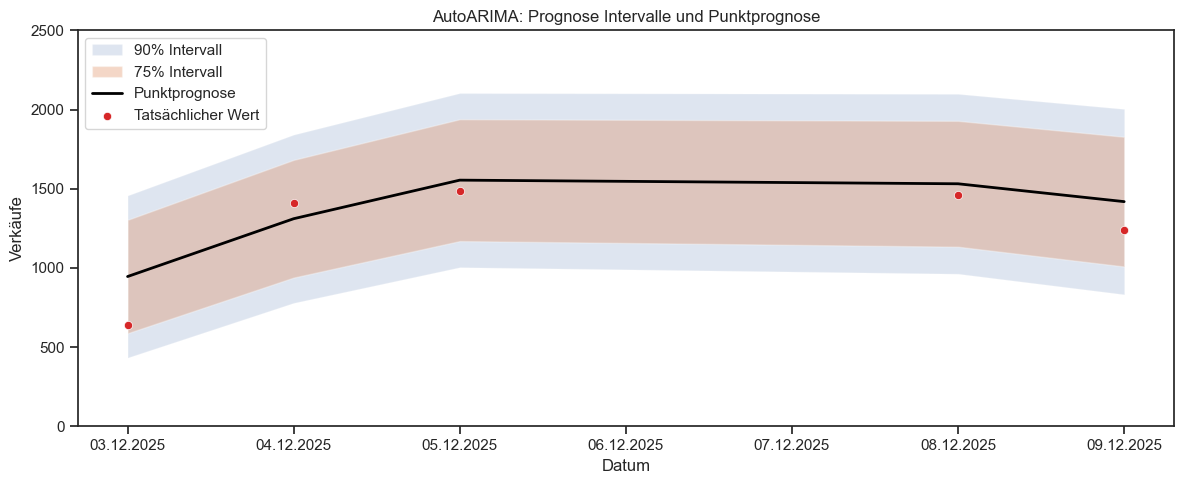

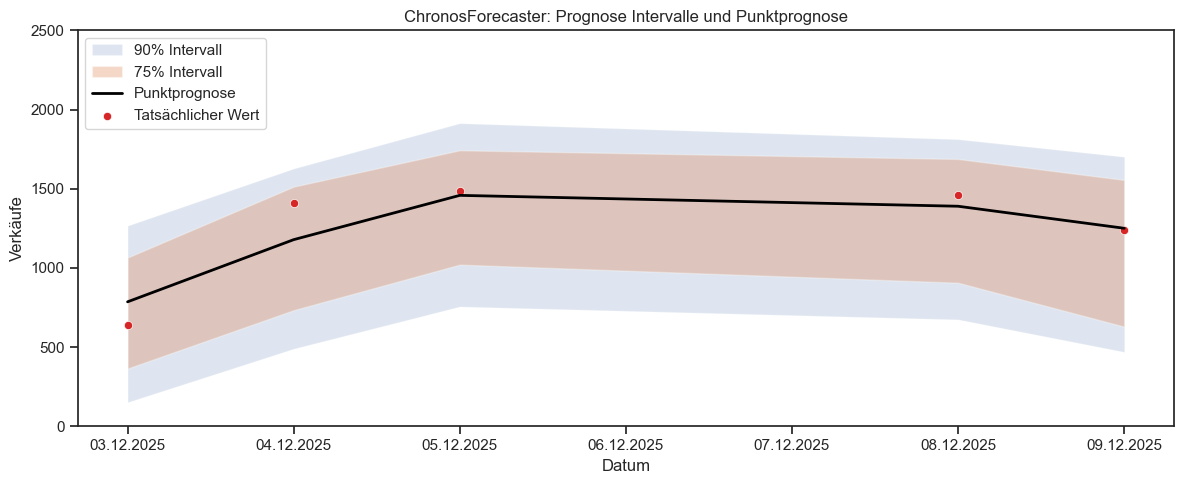

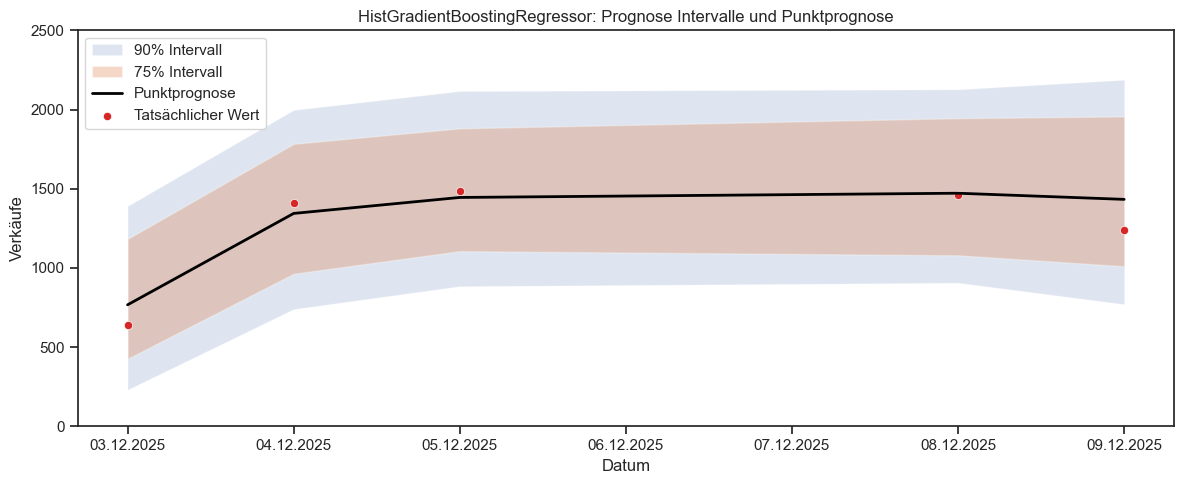

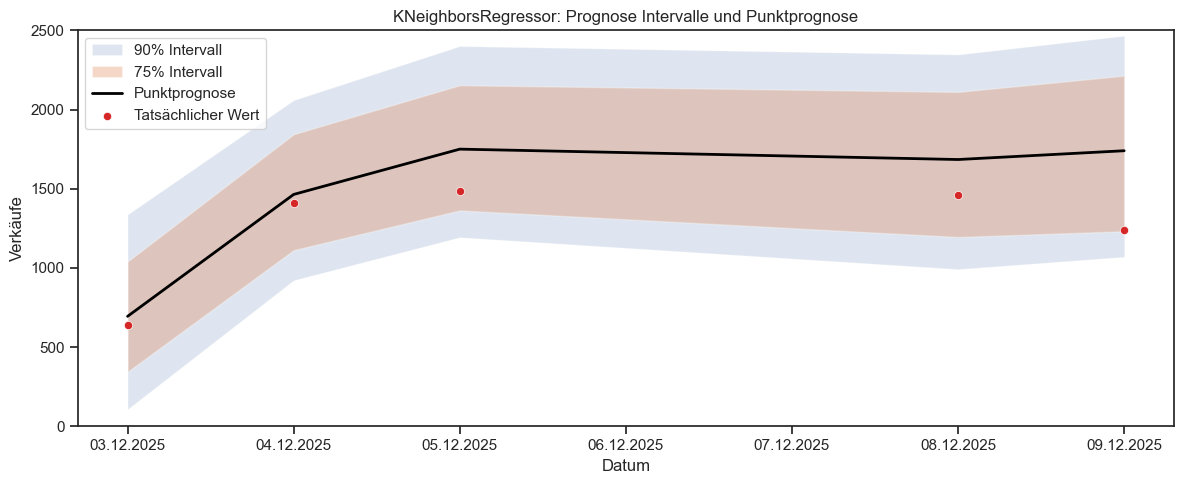

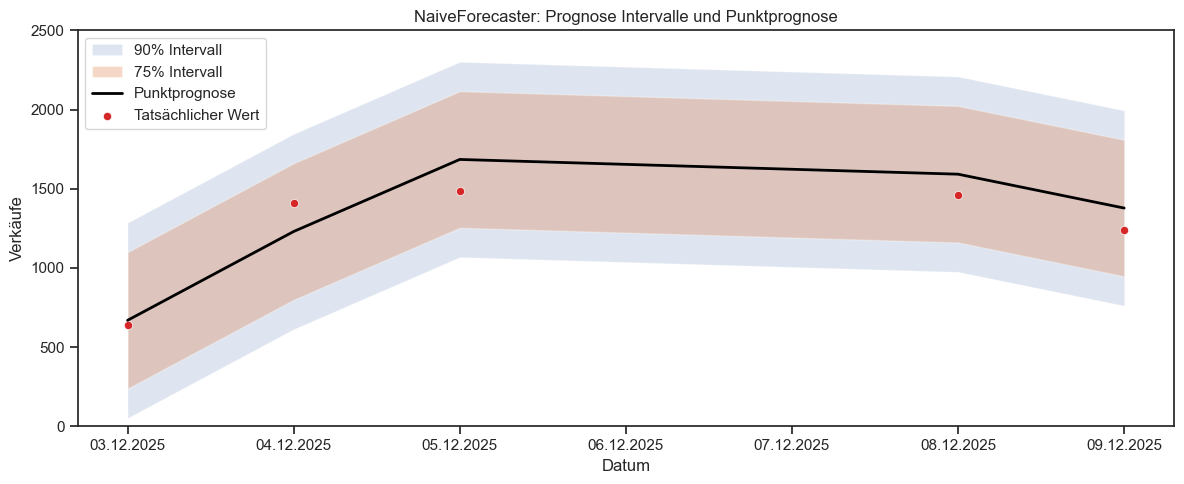

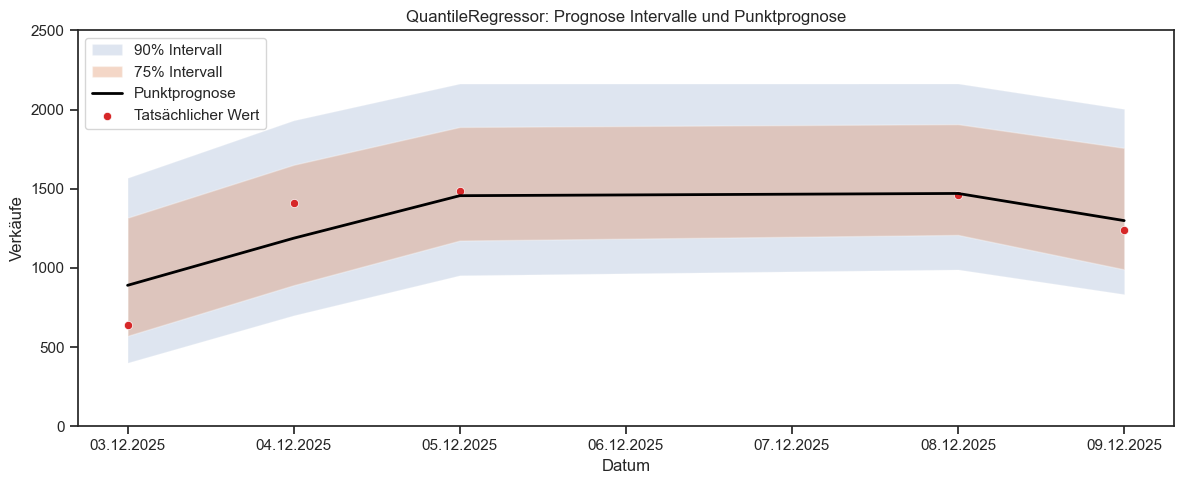

In [115]:
sns.set_theme(style="ticks")

for model, g in plot_df.groupby("model_clean"):
    fig, ax = plt.subplots(figsize=(12, 5))

    g75 = g[g["coverage"] == 0.75].sort_values("index")
    g90 = g[g["coverage"] == 0.90].sort_values("index")

    ax.fill_between(g90["index"], g90["lower"], g90["upper"], alpha=0.18, label="90% Intervall")
    ax.fill_between(g75["index"], g75["lower"], g75["upper"], alpha=0.32, label="75% Intervall")

    sns.lineplot(data=g75, x="index", y="point_forecast", ax=ax, color="black", linewidth=2, label="Punktprognose")
    sns.scatterplot(data=g75, x="index", y="y_true", ax=ax, color="tab:red", s=35, label="Tatsächlicher Wert")

    ax.set_title(f"{model}: Prognose Intervalle und Punktprognose")
    ax.set_xlabel("Datum")
    ax.set_ylabel("Verkäufe")
    ax.set_ybound(0, 2500)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

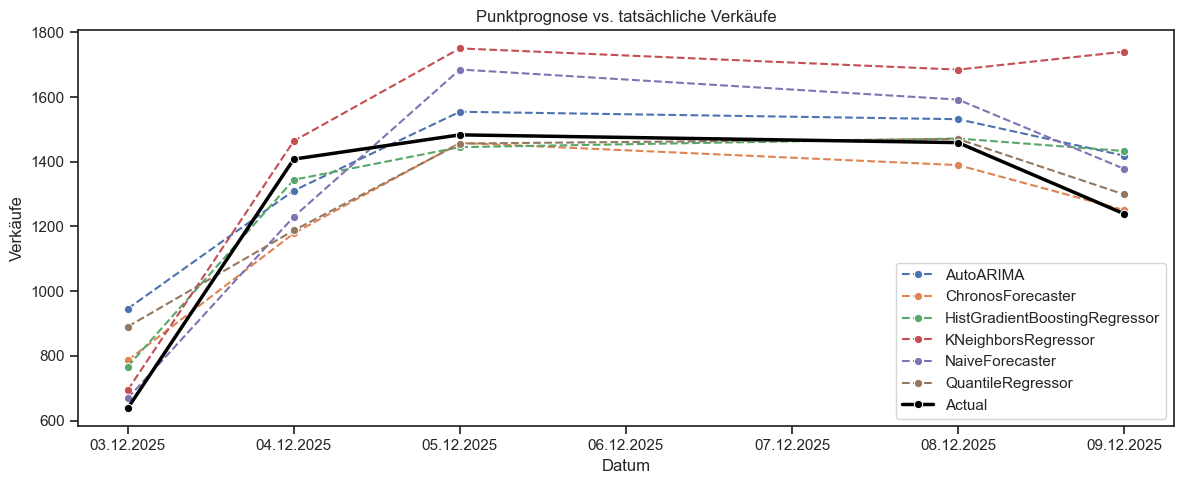

In [117]:
point_df = (
    plot_df
    .sort_values(["model_clean", "index", "coverage"])
    .drop_duplicates(subset=["model_clean", "index"])
)

sns.set_theme(style="ticks")

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=point_df,
    x="index",
    y="point_forecast",
    hue="model_clean",
    marker="o",
    linestyle="--",
)

sns.lineplot(
    data=point_df.drop_duplicates(subset=["index"]),
    x="index",
    y="y_true",
    color="black",
    linewidth=2.5,
    marker="o",
    label="Actual",
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y"))

plt.title("Punktprognose vs. tatsächliche Verkäufe")
plt.xlabel("Datum")
plt.ylabel("Verkäufe")
plt.tight_layout()
plt.show()